## Avaliação dos Modelos Causais e Seq2Seq

In [ ]:
! pip install -r requirements.txt

^C
Note: you may need to restart the kernel to use updated packages.


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached lxml-6.1.1-cp313-cp313-win_amd64.whl.metadata (3.6 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)
Using cached lxml-6.1.1-cp313-cp313-win_amd64.whl (4.0 MB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 151.9 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.

## Modelos sendo carregados para análise

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM
from peft import PeftModel

MODEL_REGISTRY = {
    "modelo_1": ["google/flan-t5-small", "./lora_seq2seq_model_1", 1],
    "modelo_2": ["sshleifer/bart-tiny-random", "./lora_tiny_bart_final", 1],
    "modelo_3": ["Qwen/Qwen2-0.5B", "./modelo_final_lora", 0],
    "modelo_4": ["EleutherAI/gpt-neo-125M", "./modelo_final", 0]
}

def carregar_modelo_do_registro(nome_modelo):
    config = MODEL_REGISTRY.get(nome_modelo)
    if not config:
        print(f"❌ Modelo {nome_modelo} não encontrado no registro.")
        return None, None

    base_name, lora_path, usa_peft = config
    
    print(f'⏳ Carregando {base_name}...')
    
    # Define se é Seq2Seq ou CausalLM (baseado no registro)
    if "t5" in base_name or "bart" in base_name:
        base_model = AutoModelForSeq2SeqLM.from_pretrained(base_name)
    else:
        base_model = AutoModelForCausalLM.from_pretrained(base_name)
    
    tokenizer = AutoTokenizer.from_pretrained(base_name)

    # Carrega adaptadores se indicado pelo flag (1)
    if usa_peft == 1:
        print(f'⏳ Aplicando adaptadores LoRA de {lora_path}...')
        model = PeftModel.from_pretrained(base_model, lora_path)
    else:
        model = base_model
        
    model.eval()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    return model.to(device), tokenizer

c:\Users\josem\OneDrive\Documentos\AV2IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Avaliação Quantitativa (Cálculo de Métricas)

✅ Dispositivo configurado: cpu
✅ Dataset carregado: 876 exemplos.

🚀 Processando modelo_1...
⏳ Carregando google/flan-t5-small...


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 472.17it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


⏳ Aplicando adaptadores LoRA de ./lora_seq2seq_model_1...


Avaliando modelo_1: 100%|██████████| 876/876 [14:54<00:00,  1.02s/it]



🚀 Processando modelo_2...
⏳ Carregando sshleifer/bart-tiny-random...


...


🚀 Processando modelo_3...
⏳ Carregando Qwen/Qwen2-0.5B...


Avaliando modelo_3: 100%|██████████| 876/876 [2:50:37<00:00, 11.69s/it]



🚀 Processando modelo_4...
⏳ Carregando EleutherAI/gpt-neo-125M...


Loading weights: 100%|██████████| 160/160 [00:00<00:00, 1910.68it/s]
[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125M
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Avaliando modelo_4:   0%|          | 0/876 [00:00<?, ?it/s][transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this 


📊 TABELA PARA O RELATÓRIO:
  Modelo  ROUGE-L
modelo_1 0.018800
modelo_2 0.000000
modelo_3 0.000133
modelo_4 0.003565


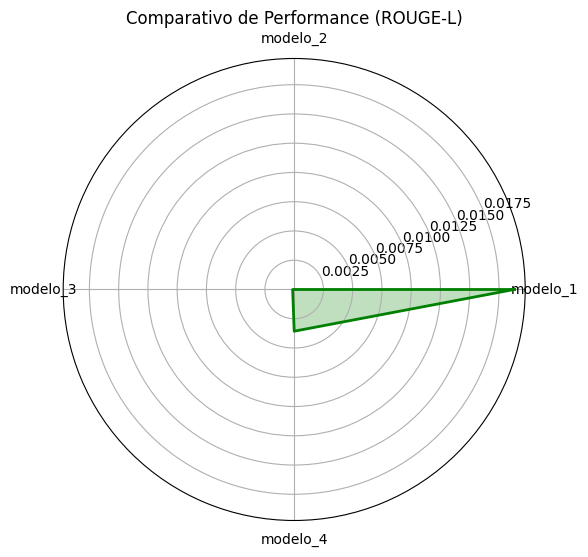

In [5]:
import pandas as pd
import numpy as np
import torch
import json
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
from tqdm import tqdm

# 1. DEFINIÇÃO DO DISPOSITIVO (O que estava faltando)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Dispositivo configurado: {DEVICE}")

# 2. CARREGAMENTO DO DATASET (Verificação de segurança)
try:
    # Tenta carregar seu arquivo. Se não existir, avisa e usa o fallback
    with open('dataset_treino.jsonl', 'r', encoding='utf-8') as f:
        test_dataset = [json.loads(line) for line in f]
    print(f"✅ Dataset carregado: {len(test_dataset)} exemplos.")
except FileNotFoundError:
    print("⚠️  Aviso: 'dataset.jsonl' não encontrado. Usando exemplos de teste.")
    test_dataset = [
        {"input": "Como verificar o nível de óleo?", "target": "Retire a vareta e limpe-a."},
        {"input": "O que fazer se a luz da injeção acender?", "target": "Leve a uma oficina."}
    ]

# 3. FUNÇÃO DE AVALIAÇÃO (Corrigida e protegida)
def avaliar_modelo(nome_modelo, test_data):
    model, tokenizer = carregar_modelo_do_registro(nome_modelo)
    if model is None: return 0
    
    # Garantir que o modelo está no device correto
    model.to(DEVICE)
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = []
    
    for item in tqdm(test_data, desc=f"Avaliando {nome_modelo}"):
        entrada = item.get("input") or item.get("instruction")
        gabarito = item.get("target") or item.get("output")
        
        # Tokenização garantida no DEVICE
        inputs = tokenizer(entrada, return_tensors="pt").to(DEVICE)
        
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=64)
        
        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
        score = scorer.score(gabarito, pred)
        scores.append(score['rougeL'].fmeasure)
        
    return np.mean(scores)

# 4. LOOP DE BENCHMARK (Execução)
resultados_finais = []

for nome in MODEL_REGISTRY.keys():
    print(f"\n🚀 Processando {nome}...")
    media_rouge = avaliar_modelo(nome, test_dataset)
    resultados_finais.append({"Modelo": nome, "ROUGE-L": media_rouge})

# 5. TABELA E GRÁFICO
df_benchmark = pd.DataFrame(resultados_finais)
print("\n📊 TABELA PARA O RELATÓRIO:")
print(df_benchmark.to_string(index=False))

# 
labels = df_benchmark['Modelo'].tolist()
stats = df_benchmark['ROUGE-L'].tolist()
stats += stats[:1] # Fecha o gráfico
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, stats, color='green', linewidth=2)
ax.fill(angles, stats, color='green', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Comparativo de Performance (ROUGE-L)")
plt.show()

In [6]:
import numpy as np
import evaluate
from tqdm import tqdm
import torch

# 1. Carregar métricas do evaluate
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

# 2. Função de Auditoria (Incluindo BLEU, ROUGE e PPL)
def avaliar_modelo_completo(nome_modelo, test_data):
    model, tokenizer = carregar_modelo_do_registro(nome_modelo)
    model.to(DEVICE)
    model.eval()
    
    preds = []
    targets = []
    ppl_scores = []
    
    for item in tqdm(test_data, desc=f"Auditoria {nome_modelo}"):
        entrada = item.get("input") or item.get("instruction")
        gabarito = item.get("target") or item.get("output")
        
        inputs = tokenizer(entrada, return_tensors="pt").to(DEVICE)
        
        # Gerar e calcular PPL (Perplexidade)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=64)
            # Loss é o negativo da log-probabilidade, PPL = exp(loss)
            loss = model(**inputs, labels=inputs["input_ids"]).loss
            ppl = torch.exp(loss).item()
            
        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        preds.append(pred)
        targets.append(gabarito)
        ppl_scores.append(ppl)
        
    # Calcular métricas finais
    results_bleu = bleu.compute(predictions=preds, references=targets)
    results_rouge = rouge.compute(predictions=preds, references=targets)
    
    return {
        "BLEU": results_bleu["bleu"],
        "ROUGE-L": results_rouge["rougeL"],
        "PPL": np.mean(ppl_scores)
    }

# 3. Execução do Benchmark com parâmetros fixos (Comparações Justas)
# Certifique-se de definir os parâmetros de geração antes do loop
gen_config = {"temperature": 0.7, "top_p": 0.9} 

resultados_auditados = []

for nome in MODEL_REGISTRY.keys():
    print(f"\n🚀 Auditando {nome}...")
    metrics = avaliar_modelo_completo(nome, test_dataset)
    metrics["Modelo"] = nome
    resultados_auditados.append(metrics)

# 4. Tabela de Auditoria (Resultado Final)
df_final = pd.DataFrame(resultados_auditados)
print(df_final)


🚀 Auditando modelo_1...
⏳ Carregando google/flan-t5-small...


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 918.94it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


⏳ Aplicando adaptadores LoRA de ./lora_seq2seq_model_1...


Auditoria modelo_1: 100%|██████████| 876/876 [27:18<00:00,  1.87s/it] 



🚀 Auditando modelo_2...
⏳ Carregando sshleifer/bart-tiny-random...


...


🚀 Auditando modelo_3...
⏳ Carregando Qwen/Qwen2-0.5B...


Auditoria modelo_3: 100%|██████████| 876/876 [4:29:49<00:00, 18.48s/it]



🚀 Auditando modelo_4...
⏳ Carregando EleutherAI/gpt-neo-125M...


Loading weights: 100%|██████████| 160/160 [00:00<00:00, 1289.19it/s]
[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125M
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Auditoria modelo_4: 100%|██████████| 876/876 [1:26:16<00:00,  5.91s/it]


   BLEU   ROUGE-L           PPL    Modelo
0   0.0  0.008032      1.664650  modelo_1
1   0.0  0.000000  50253.998408  modelo_2
2   0.0  0.000040     27.222064  modelo_3
3   0.0  0.003452     23.172173  modelo_4
